In [1]:
import pandas as pd
import RNA
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LassoCV,ElasticNetCV,LogisticRegressionCV,LogisticRegression,LinearRegression
from concurrent.futures import ProcessPoolExecutor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from sklearn.metrics import roc_curve, auc

# First library

In [3]:
# ---- Chargement et filtrage des données ----
df = pd.read_csv('../Summary_all.csv')
df=df[df['Library']=='Lib_1']
df=df[df['TR_count']>1000]
df=df[np.array([len(t) for t in df['TR']])==70]
df_average = df.groupby('TR')['percentage_mutants'].mean().reset_index()

df_average.to_csv('Lib_1_percentages.csv')

df_average["label"] = df_average["percentage_mutants"].apply(
    lambda x: 1 if x > 10 else (0 if x < 0.3 else None)
)

df_average = df_average.dropna(subset=["label"]).reset_index(drop=True)
# ---- Extraction des features ----
TR = df_average["TR"].tolist()
y = np.array(df_average["label"].astype(int).tolist())

def base_pairing_probability_array(sequence):
    rna_seq = sequence.replace('T', 'U')

    fc = RNA.fold_compound(rna_seq)
    (propensity, ensemble_energy) = fc.pf()
    basepair_probs = fc.bpp()
    mfe=fc.mfe()
    mea=fc.MEA()
    entropy= fc.positional_entropy()
    return (mfe[0],mfe[1],mea[0],mea[1],ensemble_energy,np.array(basepair_probs),np.array(entropy)[1:])

def features(sequence,e_tr):
    feature_list=[]
    structure_mfe,mfe,structure_mea,mea,ensemble_energy,bpp,entropy=base_pairing_probability_array(sequence)
    feature_list.append(mfe)
    feature_list.append(mea)
    feature_list.append(ensemble_energy)
    feature_list.append(mfe-e_tr[1])
    feature_list.append(mea-e_tr[2])
    feature_list.append(ensemble_energy-e_tr[0])
    feature_list.extend(list(entropy))
    feature_list.extend(list(np.max(bpp,axis=0)))
    return feature_list

def sliding_window_feature(sequence, window_size, window_shift,e_tr):
    sliding_feature_list = []
    seq_len = len(sequence)
    # nombre de fenêtres possibles (fenêtre complètement dans la séquence)
    num_windows = 1 + (seq_len - window_size) // window_shift
    for start in range(0, num_windows * window_shift, window_shift):
        window_seq = sequence[start:start+window_size]
        sliding_feature_list.extend(features(window_seq,e_tr))
    return sliding_feature_list

# Séquences de base
Sp = 'TCTGTGCCCATCACCTTCTTGCATGGCTCTGCCAACGCTACGGCTTGGCGGGCTGGCCTTTCCTCAATAGGTGGTCAGCCGGTTCTGTCCTGCTTCGGCGAACACGTTACACGGTTCGGCAAAACGTCGATTACTGAAAATGGAAAGGCGGGGCCGACTTC'
Avd = 'AAGGGCAGGCTGGGAAATAA'

X = []
for k in tqdm(range(len(TR))):
    t = TR[k]
    fc = RNA.fold_compound(t)
    (propensity, ensemble_energy) = fc.pf()
    mfe=fc.mfe()[1]
    mea=fc.MEA()[1]
    e_tr=(ensemble_energy,mfe,mea)
    seq = Avd + t + Sp
    # Fenêtres taille 70
    feat_70 = sliding_window_feature(seq, 70, len(Avd),e_tr)
    # Fenêtres taille 100
    feat_100 = sliding_window_feature(seq, 100, len(Avd),e_tr)
    # Concaténation des features des deux tailles
    X.append(feat_70 + feat_100)
X = np.array(X)

# Calcul des nombres de fenêtres pour chaque taille
seq_len = len(Avd) + len(TR[0]) + len(Sp)
num_windows_1 = 1 + (seq_len - 70) // len(Avd)
num_windows_2 = 1 + (seq_len - 100) // len(Avd)

def get_feat_per_window(seq):
    structure_mfe, mfe, structure_mea, mea, ensemble_energy, bpp, entropy = base_pairing_probability_array(seq)
    entropy_len = len(entropy)
    bpp_dim0, bpp_dim1 = bpp.shape
    return 6 + entropy_len + bpp_dim1  # 3+3 ΔE + entropy + max_bpp_axis0 (sans axis1)

feat_per_window_1 = get_feat_per_window('A'*70)
feat_per_window_2 = get_feat_per_window('A'*100)

print(f"Features per window (70): {feat_per_window_1}")
print(f"Features per window (100): {feat_per_window_2}")

total_expected = num_windows_1 * feat_per_window_1 + num_windows_2 * feat_per_window_2
print(f"Total expected features: {total_expected}")

# Construction noms features
feature_names = []

# Fenêtres taille 70
entropy_len = len(base_pairing_probability_array('A'*70)[6])
bpp_dim0, bpp_dim1 = base_pairing_probability_array('A'*70)[5].shape

for w in range(num_windows_1):
    prefix = f"_from_{w*20}_to_{w*20+70}"
    feature_names.extend([
         "\nMFE"+prefix,
         "\nMEA"+prefix,
        "\nE"+prefix,
         "\nΔMFE"+prefix,
        "\nΔMEA_"+prefix,
        "\nΔE"+prefix
    ])
    for i in range(entropy_len):
        feature_names.append(f"entropy_{i}"+prefix)
    for i in range(bpp_dim1):
        feature_names.append( f"max_bpp_{i}"+prefix)

# Fenêtres taille 100
entropy_len = len(base_pairing_probability_array('A'*100)[6])
bpp_dim0, bpp_dim1 = base_pairing_probability_array('A'*100)[5].shape

for w in range(num_windows_2):
    prefix = f"_from_{w*20}_to_{w*20+100}"
    feature_names.extend([
         "\nMFE"+prefix,
         "\nMEA"+prefix,
        "\nE"+prefix,
        "\nΔMFE"+prefix,
        "\nΔMEA"+prefix,
        "\nΔE"+prefix
    ])
    for i in range(entropy_len):
        feature_names.append( f"\nentropy_{i}"+prefix)
    for i in range(bpp_dim1):
        feature_names.append(f"\nmax_bpp_{i}"+prefix)

100%|█████████████████████████████████████████| 144/144 [00:49<00:00,  2.94it/s]

Features per window (70): 147
Features per window (100): 207
Total expected features: 3126


## Fig S1 (a)

Average balanced ROC-AUC over 100 runs: 0.761 plus minus 0.044
Average balanced accuracy over 100 runs: 0.714 plus minus 0.037
Number of features: 3126

Top features (by |average weight|):

ΔE_from_20_to_120: 0.1973

max_bpp_79_from_20_to_120: -0.0126


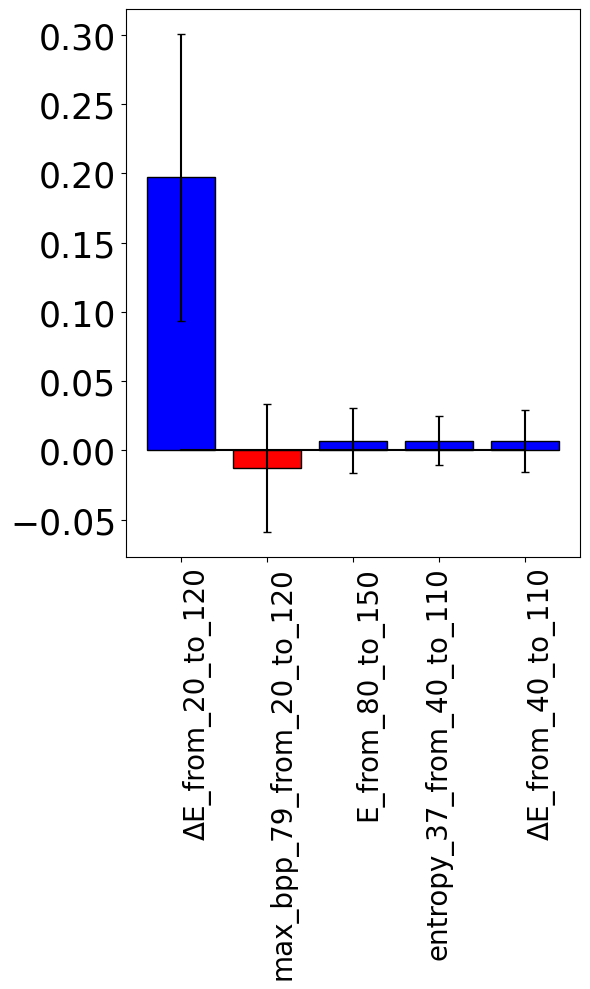

In [4]:
# --- Parameters ---
n_runs = 100   # number of random train/test splits
test_size = 0.2
C_value = 0.05

# --- Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Storage ---
all_coefs = []
all_auc = []
all_bacc = []

for run in range(n_runs):
    # Random split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, stratify=y, random_state=run
    )

    # Logistic Regression with L1 penalty and fixed C
    clf = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        C=C_value
    )
    clf.fit(X_train, y_train)

    # Store coefficients
    all_coefs.append(clf.coef_.ravel())

    # Predictions for metrics
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    all_auc.append(roc_auc_score(y_test, y_prob))
    all_bacc.append(balanced_accuracy_score(y_test, y_pred))

# --- Averages ---
avg_coefs = np.mean(all_coefs, axis=0)
avg_auc = np.mean(all_auc)
avg_bacc = np.mean(all_bacc)

print(f"Average balanced ROC-AUC over {n_runs} runs: {avg_auc:.3f} plus minus {2*np.std(all_auc)/np.sqrt(19):.3f}")
print(f"Average balanced accuracy over {n_runs} runs: {avg_bacc:.3f} plus minus {2*np.std(all_bacc)/np.sqrt(19):.3f}")
print(f"Number of features: {len(avg_coefs)}")

# --- Show top non-zero averaged coefficients ---
print("\nTop features (by |average weight|):")
for coef, name in sorted(zip(avg_coefs, feature_names), key=lambda x: -abs(x[0]))[:30]:
    if abs(coef) > 1e-2:
        print(f"{name}: {coef:.4f}")

# Visualisation
import matplotlib.pyplot as plt

# --- Moyenne et écart-type des coefficients ---
avg_coefs = np.mean(all_coefs, axis=0)
std_coefs = np.std(all_coefs, axis=0)

# Filtrer les coefficients non nuls
non_zero_indices = np.where(np.abs(avg_coefs) > 5e-3)[0]
non_zero_avg = avg_coefs[non_zero_indices]
non_zero_std = std_coefs[non_zero_indices]
non_zero_names = np.array(feature_names)[non_zero_indices]

# Trier par valeur absolue moyenne
sorted_indices = np.argsort(-np.abs(non_zero_avg))
sorted_avg = non_zero_avg[sorted_indices]
sorted_std = non_zero_std[sorted_indices]
sorted_names = non_zero_names[sorted_indices]

plt.figure(figsize=(6, 10))
colors = ['red' if c < 0 else 'blue' for c in sorted_avg]
plt.plot(range(len(sorted_avg)),0*np.arange(len(sorted_avg)),'-k')
# Use bar plot with signed y values
plt.bar(
    range(len(sorted_avg)),
    sorted_avg,  # Use signed values
    color=colors,
    yerr=sorted_std,
    capsize=3,
    edgecolor='black'
)

plt.xticks(range(len(sorted_names)), sorted_names, rotation=90, fontsize=20)
plt.yticks(fontsize=25)
plt.tight_layout()

## Fig S1 (b)

In [5]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})


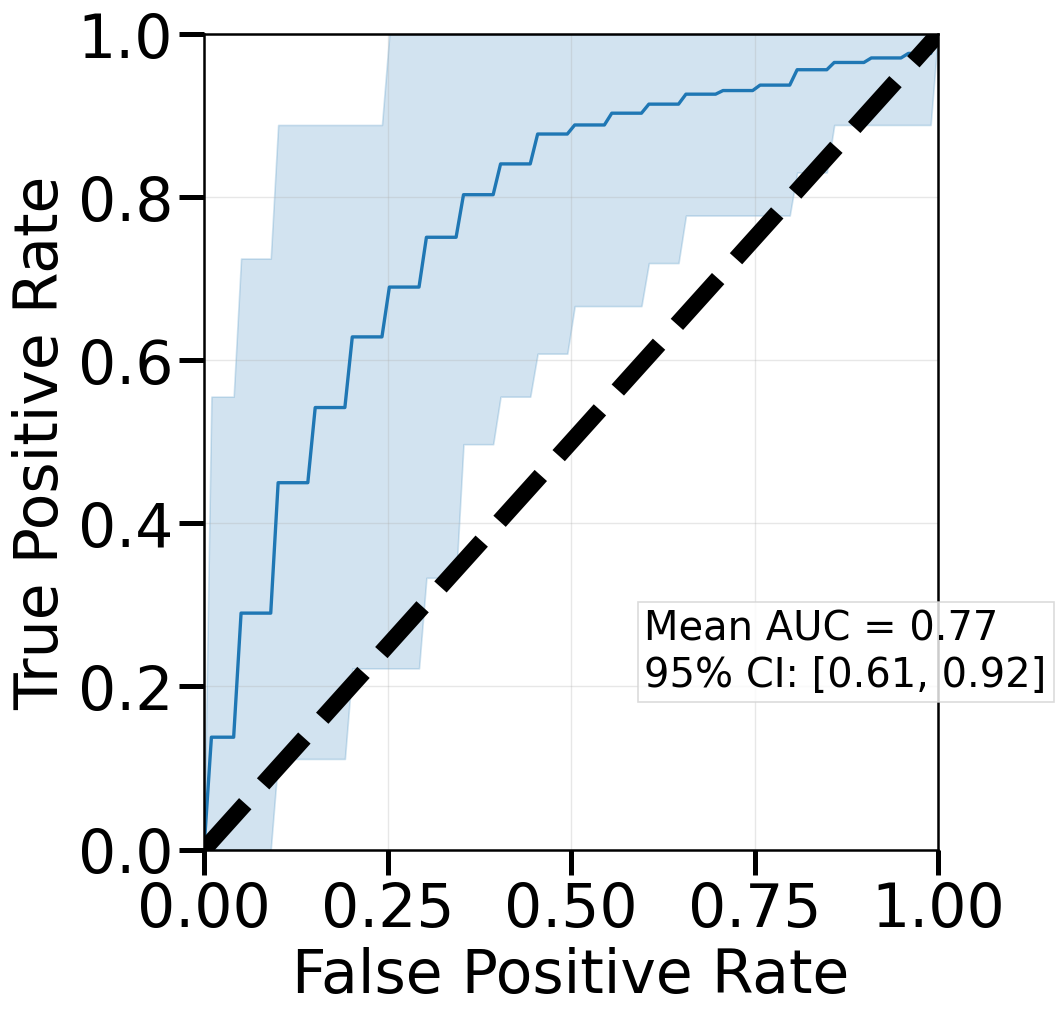

In [6]:


n_splits = 100
fpr_grid = np.linspace(0, 1, 100)  # Common FPR grid for interpolation

tpr_runs = []
auc_runs = []

for seed in range(n_splits):
    # Split dataset randomly
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Logistic Regression with L1 penalty and fixed C
    clf = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        C=C_value
    )
    clf.fit(X_train, y_train)
    y_proba_test = clf.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test, pos_label=1)
    roc_auc = auc(fpr, tpr)
    auc_runs.append(roc_auc)

    # Interpolate TPR to common FPR grid
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_interp[0] = 0.0  # Ensure TPR starts at 0 for FPR=0
    tpr_runs.append(tpr_interp)

# Convert to array
tpr_runs = np.array(tpr_runs)

# Mean and 95% CI for TPR across runs
tpr_mean = np.mean(tpr_runs, axis=0)
tpr_lower = np.percentile(tpr_runs, 2.5, axis=0)  # 2.5th percentile
tpr_upper = np.percentile(tpr_runs, 97.5, axis=0)  # 97.5th percentile

# Mean and 95% CI for AUC
mean_auc = np.mean(auc_runs)
ci_lower_auc = np.percentile(auc_runs, 2.5)
ci_upper_auc = np.percentile(auc_runs, 97.5)

# --- Plot ---
plt.figure(figsize=(9, 9))
plt.plot(fpr_grid, tpr_mean, color="C0", lw=2, label=f"Average ROC curve (AUC = {mean_auc:.2f})")
plt.fill_between(
    fpr_grid,
    tpr_lower,
    tpr_upper,
    color="C0",
    alpha=0.2,
    label="95% CI (TPR)"
)

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", color="k", lw=10)

# Labels and limits
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add text box with AUC stats
plt.text(
    0.6, 0.2,
    f"Mean AUC = {mean_auc:.2f}\n95% CI: [{ci_lower_auc:.2f}, {ci_upper_auc:.2f}]",
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.8)
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Second library

In [2]:
# ---- Chargement et filtrage des données ----
df = pd.read_csv('../Summary_all.csv')

df=df[df['TR_count']>1000]
df_2=df[df['Library']=="Lib_2"]

df_2 = df_2.groupby('TR')['percentage_mutants'].mean().reset_index()
print(len(df_2))
# keep only rows that meet either condition
df_sub=df_2[
    (df_2['percentage_mutants'] < 2) |
    (df_2['percentage_mutants'] > 10)]
TR = list(df_sub['TR'])

# assign labels
y = np.where(
    df_sub['percentage_mutants'] < 2, 0, 1
)

def feature(seq):
    Sp = 'TCTGTGCCCATCACCTTCTTGCATGGCTCTGCCAACGCTACGGCTTGGCGGGCTGGCCTTTCCTCAATAGGTGGTCAGCCGGTTCTGTCCTGCTTCGGCGAACACGTTACACGGTTCGGCAAAACGTCGATTACTGAAAATGGAAAGGCGGGGCCGACTTC'
    Avd = 'AAGGGCAGGCTGGGAAATAA'
    features = []

    # Base folding energy of TR alone (partition function)
    fc_base = RNA.fold_compound(seq)
    _, e_tr = fc_base.pf()

    # ΔE with Sp window
    for window in [10,15,20,25,30,35]:
        sp_window = Sp[:window]
        fc_sp = RNA.fold_compound(seq + sp_window)
        _, e_tr_sp = fc_sp.pf()
        features.append(e_tr_sp - e_tr)
        # ΔE with Avd + TR + Sp
        fc_combo = RNA.fold_compound(Avd + seq + sp_window)
        _, e_tr_combo = fc_combo.pf()
        features.append(e_tr_combo - e_tr)

    # GC, G, C content
    gc = (seq.count('G') + seq.count('C')) / len(seq)
    g = seq.count('G') / len(seq)
    c = seq.count('C') / len(seq)
    features.extend([gc, g, c])

    # ==== TR BPP matrix ====
    fc_base.pf()
    bpp_tr = fc_base.bpp()  # 2D numpy array: (n+1, n+1)
    n = len(seq)

    # Top 10 TR–TR base pair probabilities (upper triangle only)
    top_tr_probs = sorted(
        [bpp_tr[i][j] for i in range(1, n + 1) for j in range(i + 1, n + 1)],
        reverse=True
    )[:10]
    features.extend(top_tr_probs + [0.0] * (10 - len(top_tr_probs)))

    # Marginal BPP per base
    marginal_probs = [sum(bpp_tr[i][j] for j in range(1, n + 1) if i != j) for i in range(1, n + 1)]
    top_marginals = sorted(marginal_probs, reverse=True)[:10]
    features.extend(top_marginals + [0.0] * (10 - len(top_marginals)))

    # Total TR–TR base-pair probability
    total_tr_bpp = sum(bpp_tr[i][j] for i in range(1, n + 1) for j in range(i + 1, n + 1))

    # ==== TR-other (contextual) pairing ====
    full_seq = Avd + seq + sp_window
    fc_full = RNA.fold_compound(full_seq)
    fc_full.pf()
    bpp_full = fc_full.bpp()
    full_len = len(full_seq)
    offset_start = len(Avd) + 1
    offset_end = offset_start + len(seq) - 1

    tr_other_probs = []
    for i in range(offset_start, offset_end + 1):
        for j in range(1, full_len + 1):
            if j < offset_start or j > offset_end:
                tr_other_probs.append(bpp_full[i][j])

    top_cross_probs = sorted(tr_other_probs, reverse=True)[:10]
    total_tr_other_bpp = sum(tr_other_probs)

    features.extend(top_cross_probs + [0.0] * (10 - len(top_cross_probs)))
    features.extend([total_tr_bpp, total_tr_other_bpp])

    return features



# Séquences de base
Sp = 'TCTGTGCCCATCACCTTCTTGCATGGCTCTGCCAACGCTACGGCTTGGCGGGCTGGCCTTTCCTCAATAGGTGGTCAGCCGGTTCTGTCCTGCTTCGGCGAACACGTTACACGGTTCGGCAAAACGTCGATTACTGAAAATGGAAAGGCGGGGCCGACTTC'
Avd = 'AAGGGCAGGCTGGGAAATAA'

X = []
for k in tqdm(range(len(TR))):
    X.append(feature(TR[k]))

X = np.array(X)

feature_names = []

# ΔE features for Sp windows
for window in [10, 15, 20, 25, 30, 35]:
    feature_names.append(f"ΔE_TR+Sp{window}")
    feature_names.append(f"ΔE_Avd+TR+Sp{window}")

# Base composition
feature_names.extend(["GC_content", "G_content", "C_content"])

# Top 10 TR–TR BPP
feature_names.extend([f"Top_TR_BP_{i+1}" for i in range(10)])

# Top 10 marginal BPPs
feature_names.extend([f"Top_Marginal_{i+1}" for i in range(10)])

# Total TR–TR BPP
feature_names.append("Total_TR_TR_BPP")

# Top 10 TR-other BPPs
feature_names.extend([f"Top_TR_Other_{i+1}" for i in range(10)])

# Total TR-other BPP
feature_names.append("Total_TR_Other_BPP")

460


100%|█████████████████████████████████████████| 262/262 [02:45<00:00,  1.58it/s]


## Fig S1 (c)

Average balanced ROC-AUC over 100 runs: 0.909 plus minus 0.017
Average balanced accuracy over 100 runs: 0.839 plus minus 0.021
Number of features: 47

Top features (by |average weight|):
ΔE_Avd+TR+Sp15: 0.8826
ΔE_Avd+TR+Sp30: 0.2121
C_content: -0.2086
G_content: 0.0661
ΔE_Avd+TR+Sp35: 0.0131


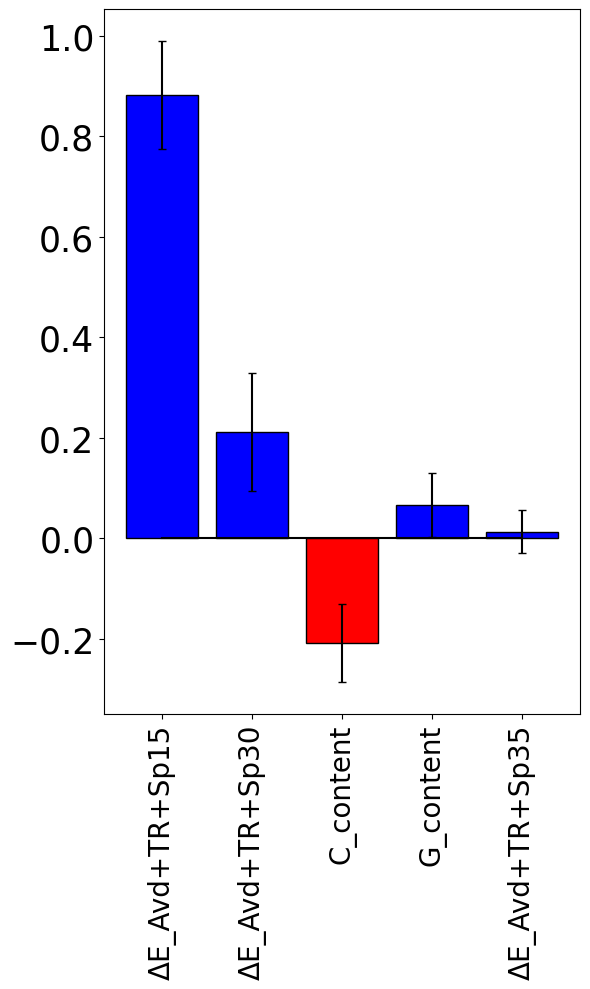

In [4]:
# --- Parameters ---
n_runs = 100   # number of random train/test splits
test_size = 0.2
C_value = 0.05

# --- Standardisation ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Storage ---
all_coefs = []
all_auc = []
all_bacc = []

for run in range(n_runs):
    # Random split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, stratify=y, random_state=run
    )

    # Logistic Regression with L1 penalty and fixed C
    clf = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        C=C_value
    )
    clf.fit(X_train, y_train)

    # Store coefficients
    all_coefs.append(clf.coef_.ravel())

    # Predictions for metrics
    y_prob = clf.predict_proba(X_test)[:, 1]
    y_pred = clf.predict(X_test)

    all_auc.append(roc_auc_score(y_test, y_prob))
    all_bacc.append(balanced_accuracy_score(y_test, y_pred))

# --- Averages ---
avg_coefs = np.mean(all_coefs, axis=0)
avg_auc = np.mean(all_auc)
avg_bacc = np.mean(all_bacc)

print(f"Average balanced ROC-AUC over {n_runs} runs: {avg_auc:.3f} plus minus {2*np.std(all_auc)/np.sqrt(19):.3f}")
print(f"Average balanced accuracy over {n_runs} runs: {avg_bacc:.3f} plus minus {2*np.std(all_bacc)/np.sqrt(19):.3f}")
print(f"Number of features: {len(avg_coefs)}")

# --- Show top non-zero averaged coefficients ---
print("\nTop features (by |average weight|):")
for coef, name in sorted(zip(avg_coefs, feature_names), key=lambda x: -abs(x[0]))[:30]:
    if abs(coef) > 1e-2:
        print(f"{name}: {coef:.4f}")

# Visualisation

# --- Moyenne et écart-type des coefficients ---
avg_coefs = np.mean(all_coefs, axis=0)
std_coefs = np.std(all_coefs, axis=0)

# Filtrer les coefficients non nuls
non_zero_indices = np.where(np.abs(avg_coefs) > 5e-3)[0]
non_zero_avg = avg_coefs[non_zero_indices]
non_zero_std = std_coefs[non_zero_indices]
non_zero_names = np.array(feature_names)[non_zero_indices]

# Trier par valeur absolue moyenne
sorted_indices = np.argsort(-np.abs(non_zero_avg))
sorted_avg = non_zero_avg[sorted_indices]
sorted_std = non_zero_std[sorted_indices]
sorted_names = non_zero_names[sorted_indices]

# --- Visualisation avec barres d'erreur ---
plt.figure(figsize=(6, 10))
colors = ['red' if c < 0 else 'blue' for c in sorted_avg]
plt.plot(range(len(sorted_avg)),0*np.arange(len(sorted_avg)),'-k')
# Use bar plot with signed y values
plt.bar(
    range(len(sorted_avg)),
    sorted_avg,  # Use signed values
    color=colors,
    yerr=sorted_std,
    capsize=3,
    edgecolor='black'
)

plt.xticks(range(len(sorted_names)), sorted_names, rotation=90, fontsize=20)
plt.yticks(fontsize=25)
plt.tight_layout()

## Fig S1 (d)

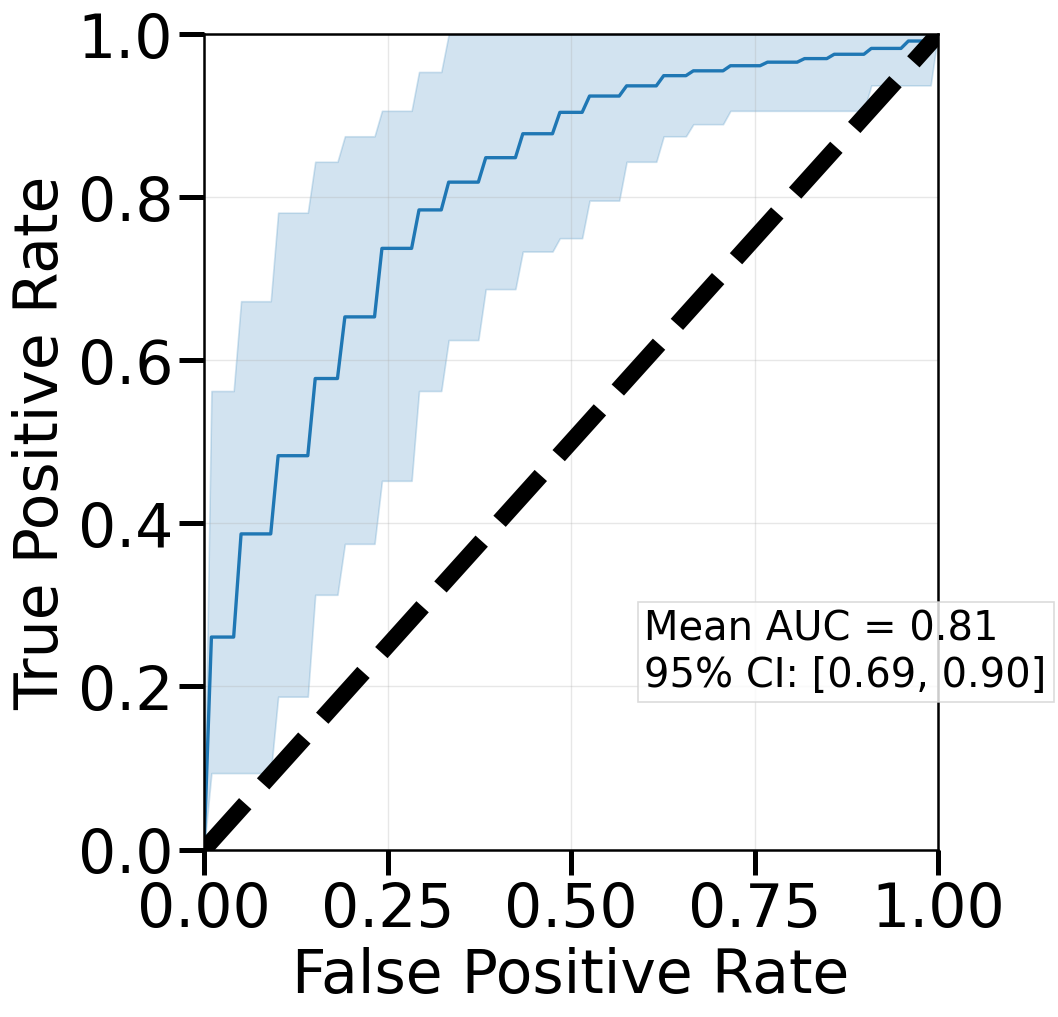

In [5]:
# GLOBAL STYLE SETTINGS (run once)

plt.rcParams.update({

    # --- FONT SIZES ---
    "font.size": 24,              # base font size
    "axes.titlesize": 20,         # title
    "axes.labelsize": 36,         # x/y labels
    "xtick.labelsize": 36,
    "ytick.labelsize": 36,
    "legend.fontsize": 16,

    # --- LINES ---
    "lines.linewidth": 5,
    "lines.markersize": 16,

    # --- FIGURE / AXIS ---
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "axes.linewidth": 1.5,        # thicker axis spines

    # --- TICKS ---
    "xtick.major.size": 15,
    "xtick.major.width": 3,
    "ytick.major.size": 15,
    "ytick.major.width": 3,

    # --- LEGEND ---
    "legend.frameon": True,
    "legend.framealpha": 0.8,
    "legend.fancybox": True,

    # --- GRID (optional) ---
    #"axes.grid": True,
    #"grid.alpha": 0.3,
})

n_splits = 100
fpr_grid = np.linspace(0, 1, 100)  # Common FPR grid for interpolation

tpr_runs = []
auc_runs = []

for seed in range(n_splits):
    # Split dataset randomly
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed, stratify=y
    )

    # Logistic Regression with L1 penalty and fixed C
    clf = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        max_iter=1000,
        class_weight='balanced',
        C=C_value
    )
    clf.fit(X_train, y_train)
    y_proba_test = clf.predict_proba(X_test)[:, 1]

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test, pos_label=1)
    roc_auc = auc(fpr, tpr)
    auc_runs.append(roc_auc)

    # Interpolate TPR to common FPR grid
    tpr_interp = np.interp(fpr_grid, fpr, tpr)
    tpr_interp[0] = 0.0  # Ensure TPR starts at 0 for FPR=0
    tpr_runs.append(tpr_interp)

# Convert to array
tpr_runs = np.array(tpr_runs)

# Mean and 95% CI for TPR across runs
tpr_mean = np.mean(tpr_runs, axis=0)
tpr_lower = np.percentile(tpr_runs, 2.5, axis=0)  # 2.5th percentile
tpr_upper = np.percentile(tpr_runs, 97.5, axis=0)  # 97.5th percentile

# Mean and 95% CI for AUC
mean_auc = np.mean(auc_runs)
ci_lower_auc = np.percentile(auc_runs, 2.5)
ci_upper_auc = np.percentile(auc_runs, 97.5)

# --- Plot ---
plt.figure(figsize=(9, 9))
plt.plot(fpr_grid, tpr_mean, color="C0", lw=2, label=f"Average ROC curve (AUC = {mean_auc:.2f})")
plt.fill_between(
    fpr_grid,
    tpr_lower,
    tpr_upper,
    color="C0",
    alpha=0.2,
    label="95% CI (TPR)"
)

# Diagonal line for random classifier
plt.plot([0, 1], [0, 1], linestyle="--", color="k", lw=10)

# Labels and limits
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# Add text box with AUC stats
plt.text(
    0.6, 0.2,
    f"Mean AUC = {mean_auc:.2f}\n95% CI: [{ci_lower_auc:.2f}, {ci_upper_auc:.2f}]",
    bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.8)
)

plt.grid(True, alpha=0.3)
plt.tight_layout()